# 🕸️ AI Swarm Detection on Twitter (X) Using NLP, DBSCAN, LightGBM, and SHAP 🕸️
**MSc Data Science Thesis Project**

---

## 📌 Project Overview

Traditional bot detection systems focus on analyzing single accounts in isolation. However, modern malicious actors deploy **swarms**—coordinated networks of automated accounts that work in synchrony to amplify fake news, manipulate trending topics, or execute disinformation campaigns. 

This notebook implements a complete **hybrid machine learning pipeline** that detects both individual malicious bots and coordinated bot swarms by fusing:
1. **Tabular Profile & Behavioral Features** (Followers, following, tweet frequency, etc.).
2. **Graph Topology Metrics** (Sampled indegree, outdegree, and neighbor ratios).
3. **NLP TF-IDF Semantic Vectorization** (Extracting language features from user tweets).
4. **Unsupervised Density-Based Clustering (DBSCAN)** (Grouping similar profiles to compute a coordinated `swarm_score`).
5. **Supervised Gradient Boosting (LightGBM)** (Final binary classification integrating all individual and swarm features).
6. **SHAP (SHapley Additive exPlanations)** (Providing full explainability into global model rankings and individual prediction features).

---

### 1. Library Imports & Environment Setup
Let's import the necessary core data science and machine learning packages and configure visual layouts.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

# Fix working directory if running inside the notebooks folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("Current working directory set to project root:", os.getcwd())

# ML and Clustering packages
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Gradient Boosting & Explainability
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print("Libraries imported successfully!")

C:\Users\srini\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Current working directory set to project root: C:\Users\srini\Desktop\AI Swarm Detection
Libraries imported successfully!


### 2. Data Ingestion
We load the raw JSON dataset (TwiBot-20 benchmark data) containing user profile metadata, tweets, relationships, and human/bot labels.

In [2]:
def load_raw_dataset(file_path):
    """Loads a JSON dataset file containing TwiBot-20 structured data."""
    print(f"[*] Loading data from: {file_path}")
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"    -> Successfully loaded {len(data)} user accounts.")
    return data

# Specify standard data paths relative to the root workspace
train_path = "data/raw/train.json"
dev_path = "data/raw/dev.json"
test_path = "data/raw/test.json"

# Load datasets
train_raw = load_raw_dataset(train_path)
dev_raw = load_raw_dataset(dev_path)
test_raw = load_raw_dataset(test_path)

[*] Loading data from: data/raw/train.json
    -> Successfully loaded 8278 user accounts.
[*] Loading data from: data/raw/dev.json
    -> Successfully loaded 2365 user accounts.
[*] Loading data from: data/raw/test.json
    -> Successfully loaded 1183 user accounts.


### 3. Exploratory Data Structure Inspection
Let's look at the fields of the very first user in the training set to understand how metadata, tweets, and labels are stored.

In [3]:
first_user = train_raw[0]
print("User keys:", first_user.keys())
print("\n--- Profile Metadata Example ---")
for key, val in list(first_user['profile'].items())[:10]:
    print(f"  {key}: {val}")
print("\n--- Sample Tweet ---")
if first_user.get('tweet'):
    print("  ", first_user['tweet'][0])
else:
    print("   No tweets found.")
print("\nLabel (0 = Human, 1 = Bot):", first_user.get('label'))

User keys: dict_keys(['ID', 'profile', 'tweet', 'neighbor', 'domain', 'label'])

--- Profile Metadata Example ---
  id: 17461978 
  id_str: 17461978 
  name: SHAQ 
  screen_name: SHAQ 
  location: Orlando, FL 
  profile_location: {'id': '55b4f9e5c516e0b6', 'url': 'https://api.twitter.com/1.1/geo/id/55b4f9e5c516e0b6.json', 'place_type': 'unknown', 'name': 'Orlando, FL', 'full_name': 'Orlando, FL', 'country_code': '', 'country': '', 'contained_within': [], 'bounding_box': None, 'attributes': {}} 
  description: VERY QUOTATIOUS, I PERFORM RANDOM ACTS OF SHAQNESS 
  url: https://t.co/7hsiK8cCKW 
  entities: {'url': {'urls': [{'url': 'https://t.co/7hsiK8cCKW', 'expanded_url': 'http://www.ShaqFuRadio.com', 'display_url': 'ShaqFuRadio.com', 'indices': [0, 23]}]}, 'description': {'urls': []}} 
  protected: False 

--- Sample Tweet ---
   RT @CarnivalCruise: 🎉 Are you ready to see what our newest ship’s name will be? 🎉 Thanks to all our partners for helping us unbox the name.…


Label (0 = Huma

### 4. Modular Feature Extraction: Profiles & Behaviors
We parse the raw profile dictionary, calculate account age relative to a reference collection date, extract boolean profile metrics, and engineer Laplace-smoothed behavioral ratios.

In [4]:
def extract_profile_features(raw_data):
    """
    Extracts tabular features from raw Twitter user profile metadata.
    """
    records = []
    reference_date = datetime(2021, 1, 1)
    
    for user in raw_data:
        profile = user.get('profile', {}) or {}
        tweets = user.get('tweet') or []
        
        # Parse creation date to compute account age in days
        created_at_str = profile.get('created_at', '')
        account_age_days = -1
        if isinstance(created_at_str, str) and created_at_str.strip():
            try:
                created_at_str = created_at_str.strip()
                dt = datetime.strptime(created_at_str, '%a %b %d %H:%M:%S %z %Y')
                account_age_days = (reference_date.replace(tzinfo=dt.tzinfo) - dt).days
            except ValueError:
                pass
        
        # Standard counts
        followers = int(profile.get('followers_count', 0) or 0)
        following = int(profile.get('friends_count', 0) or 0)
        
        # Categorical binary characteristics
        verified = str(profile.get('verified', 'False')).strip().lower() == 'true'
        default_profile = str(profile.get('default_profile', 'False')).strip().lower() == 'true'
        default_profile_image = str(profile.get('default_profile_image', 'False')).strip().lower() == 'true'
        has_extended_profile = str(profile.get('has_extended_profile', 'False')).strip().lower() == 'true'
        
        # Description and activity details
        bio_length = len(profile.get('description', '') or '')
        tweet_count = len(tweets)
        
        records.append({
            'user_id': user.get('ID', ''),
            'followers': followers,
            'following': following,
            'account_age_days': account_age_days,
            'verified': int(verified),
            'default_profile': int(default_profile),
            'default_profile_image': int(default_profile_image),
            'has_extended_profile': int(has_extended_profile),
            'bio_length': bio_length,
            'tweet_count': tweet_count,
            'label': int(user.get('label', '0'))
        })
        
    df = pd.DataFrame(records)
    
    # Handle missing ages by replacing with median
    median_age = df[df['account_age_days'] > 0]['account_age_days'].median()
    df['account_age_days'] = df['account_age_days'].replace(-1, median_age if not np.isnan(median_age) else 365)
    
    # Advanced engineered metrics
    df['follower_following_ratio'] = df['followers'] / (df['following'] + 1.0)
    df['tweets_per_day'] = df['tweet_count'] / (df['account_age_days'] + 1.0)
    
    return df

print("[*] Extracting training tabular features...")
df_train_tab = extract_profile_features(train_raw)
df_dev_tab = extract_profile_features(dev_raw)
df_test_tab = extract_profile_features(test_raw)

print(f"Extracted shapes: Train {df_train_tab.shape}, Dev {df_dev_tab.shape}, Test {df_test_tab.shape}")

[*] Extracting training tabular features...
Extracted shapes: Train (8278, 13), Dev (2365, 13), Test (1183, 13)


### 5. Modular Feature Extraction: Graph Topology Metrics
We extract network graph indicators by evaluating the sizes of the follower and following lists mapped within the `'neighbor'` attributes of the users.

In [5]:
def extract_graph_features(raw_data):
    """
    Extracts sampled indegree and outdegree from the 'neighbor' dictionary structure.
    """
    records = []
    for user in raw_data:
        neighbor = user.get('neighbor') or {}
        
        follower_list = neighbor.get('follower') or [] if isinstance(neighbor, dict) else []
        following_list = neighbor.get('following') or [] if isinstance(neighbor, dict) else []
        
        sampled_indegree = len(follower_list)
        sampled_outdegree = len(following_list)
        
        records.append({
            'user_id': user.get('ID', ''),
            'sampled_indegree': sampled_indegree,
            'sampled_outdegree': sampled_outdegree,
            'neighbor_ratio': sampled_indegree / (sampled_outdegree + 1.0)
        })
        
    return pd.DataFrame(records)

print("[*] Extracting graph network features...")
df_train_graph = extract_graph_features(train_raw)
df_dev_graph = extract_graph_features(dev_raw)
df_test_graph = extract_graph_features(test_raw)

print(f"Graph features extracted: Train {df_train_graph.shape}, Test {df_test_graph.shape}")

[*] Extracting graph network features...
Graph features extracted: Train (8278, 4), Test (1183, 4)


### 6. Natural Language Processing (NLP): TF-IDF Semantic Representation
To understand what the accounts are posting and capture common spam phrases, we concatenate each user's tweets and compute numerical text features using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization.

In [6]:
def preprocess_user_tweets(raw_data, max_tweets=10):
    """
    Concatenates a sample of tweets for each user into a single text block.
    """
    user_ids = []
    text_blocks = []
    
    for user in raw_data:
        tweets = user.get('tweet') or []
        recent_tweets = tweets[:max_tweets]
        
        # Flatten tweets into a single paragraph and clean line breaks
        text_block = " ".join([t.replace("\n", " ").strip() for t in recent_tweets])
        text_blocks.append(text_block)
        user_ids.append(user.get('ID', ''))
        
    return user_ids, text_blocks

print("[*] Preprocessing text for vectorization...")
train_ids, train_texts = preprocess_user_tweets(train_raw)
dev_ids, dev_texts = preprocess_user_tweets(dev_raw)
test_ids, test_texts = preprocess_user_tweets(test_raw)

# Fit and Transform TF-IDF Vectorizer
max_nlp_features = 100
print(f"[*] Generating TF-IDF vocabulary (Max features: {max_nlp_features})...")
vectorizer = TfidfVectorizer(max_features=max_nlp_features, stop_words='english')

train_tfidf = vectorizer.fit_transform(train_texts).toarray()
dev_tfidf = vectorizer.transform(dev_texts).toarray()
test_tfidf = vectorizer.transform(test_texts).toarray()

# Convert to DataFrames
tfidf_cols = [f'tfidf_{i}' for i in range(max_nlp_features)]
df_train_tfidf = pd.DataFrame(train_tfidf, columns=tfidf_cols)
df_train_tfidf['user_id'] = train_ids

df_dev_tfidf = pd.DataFrame(dev_tfidf, columns=tfidf_cols)
df_dev_tfidf['user_id'] = dev_ids

df_test_tfidf = pd.DataFrame(test_tfidf, columns=tfidf_cols)
df_test_tfidf['user_id'] = test_ids

print("NLP TF-IDF generation complete! 🎉")

[*] Preprocessing text for vectorization...
[*] Generating TF-IDF vocabulary (Max features: 100)...
NLP TF-IDF generation complete! 🎉


### 7. Feature Fusion
Now, we merge all profile metadata, graph topology, and NLP text features into a single, unified DataFrame on the `user_id` key for training.

In [7]:
def fuse_extracted_features(df_tab, df_graph, df_tfidf):
    """
    Performs a clean inner/left join to combine feature subsets on user_id.
    """
    df_fused = pd.merge(df_tab, df_graph, on='user_id', how='left')
    df_fused = pd.merge(df_fused, df_tfidf, on='user_id', how='left')
    return df_fused

print("[*] Fusing feature tables...")
df_train_fused = fuse_extracted_features(df_train_tab, df_train_graph, df_train_tfidf)
df_dev_fused = fuse_extracted_features(df_dev_tab, df_dev_graph, df_dev_tfidf)
df_test_fused = fuse_extracted_features(df_test_tab, df_test_graph, df_test_tfidf)

print(f"Fused train set shape: {df_train_fused.shape}")
print(f"Fused test set shape:  {df_test_fused.shape}")

[*] Fusing feature tables...
Fused train set shape: (8278, 116)
Fused test set shape:  (1183, 116)


### 8. Unsupervised Swarm Clustering (DBSCAN)
To detect **coordinated bot swarms**, we implement a density-based spatial clustering algorithm (**DBSCAN**). Unlike K-Means, DBSCAN does not assume spherical clusters and gracefully designates isolated human users as **noise (-1)**. 

We calculate the **`swarm_score`** for each account based on the size of the cluster they belong to and the proportion of bots predicted in that cluster during base modeling. Let's write the class.

In [8]:
class DBSCANSwarmDetector:
    """
    Detects coordinated bot networks using DBSCAN density-based clustering.
    Computes a swarm score representing the density and risk of the cluster.
    """
    def __init__(self, eps=0.5, min_samples=10):
        self.eps = eps
        self.min_samples = min_samples
        self.scaler = StandardScaler()
        self.dbscan = DBSCAN(eps=self.eps, min_samples=self.min_samples, metric='euclidean')
        self.cluster_stats = {}
        
    def fit_predict(self, df_features, base_labels):
        """
        Clusters features and returns the updated dataframe with 'cluster_id' and 'swarm_score'.
        """
        df_out = df_features.copy()
        
        # 1. Standardize the data prior to spatial distance calculations
        X_scaled = self.scaler.fit_transform(df_features)
        
        # 2. Run DBSCAN
        cluster_ids = self.dbscan.fit_predict(X_scaled)
        df_out['cluster_id'] = cluster_ids
        df_out['base_label'] = base_labels
        
        # 3. Calculate cluster statistics
        total_users = len(df_out)
        cluster_counts = df_out['cluster_id'].value_counts().to_dict()
        swarm_scores = np.zeros(total_users)
        
        for cid in np.unique(cluster_ids):
            mask = df_out['cluster_id'] == cid
            
            if cid == -1:
                # Noise / outliers get a score of 0.0 (uncoordinated individual accounts)
                swarm_scores[mask] = 0.0
                self.cluster_stats[cid] = {'size': cluster_counts.get(cid, 0), 'bot_ratio': 0.0, 'swarm_score': 0.0}
            else:
                # Coordinate Swarms: High score if the cluster contains a high bot proportion
                size = cluster_counts[cid]
                bot_ratio = df_out.loc[mask, 'base_label'].mean()
                
                # Swarm Score = Bot proportion * Cluster density approximation (normalized)
                density_multiplier = min(1.0, size / 100.0)
                swarm_score = bot_ratio * density_multiplier
                
                self.cluster_stats[cid] = {
                    'size': size,
                    'bot_ratio': bot_ratio,
                    'swarm_score': swarm_score
                }
                swarm_scores[mask] = swarm_score
                
        df_out['swarm_score'] = swarm_scores
        return df_out['cluster_id'].values, df_out['swarm_score'].values

print("DBSCAN Swarm Detector defined successfully! 🐝")

DBSCAN Swarm Detector defined successfully! 🐝


### 9. Step-by-Step Training of Hybrid Pipeline
To cleanly integrate unsupervised clustering without creating data leaks, we implement a **two-stage training pipeline**:
1. **Stage 1**: Train a base LightGBM classifier on standard tabular, graph, and TF-IDF features.
2. **Stage 2**: Run **DBSCAN Swarm Detector** using profile characteristics + NLP text dimensions alongside Stage 1 base predictions to calculate the `swarm_score`.
3. **Stage 3**: Fuse the unsupervised `swarm_score` alongside the base prediction probabilities using our Late Fusion formula.

In [9]:
# Separate inputs and outputs
cols_to_drop = ['user_id', 'label']

X_train = df_train_fused.drop(columns=cols_to_drop)
y_train = df_train_fused['label']

X_dev = df_dev_fused.drop(columns=cols_to_drop)
y_dev = df_dev_fused['label']

X_test = df_test_fused.drop(columns=cols_to_drop)
y_test = df_test_fused['label']

# -----------------------------------------------------
# STAGE 1: Supervised Base Model training (LightGBM)
# -----------------------------------------------------
print("[*] STAGE 1: Training LightGBM base classifier...")
base_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

base_model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

print("    -> Base model trained successfully!")

# -----------------------------------------------------
# STAGE 2: Unsupervised Swarm Clustering (DBSCAN)
# -----------------------------------------------------
print("[*] STAGE 2: Running Swarm Detection on Test set...")
# Get base predictions for the test set
y_pred_base = base_model.predict(X_test)
y_prob_base = base_model.predict_proba(X_test)[:, 1]

# Select numeric features for density spatial clustering (profile and key text fields)
clustering_cols = ['followers', 'following', 'account_age_days', 'follower_following_ratio'] + tfidf_cols[:10]

# Initialize and execute DBSCAN Swarm Detector
swarm_detector = DBSCANSwarmDetector(eps=0.7, min_samples=5)
cluster_ids, swarm_scores = swarm_detector.fit_predict(X_test[clustering_cols], y_pred_base)

n_swarms = len([cid for cid in np.unique(cluster_ids) if cid != -1])
print(f"    -> Detected {n_swarms} coordinated bot swarms inside the test set.")

# -----------------------------------------------------
# STAGE 3: Fusion and Late Combination
# -----------------------------------------------------
print("[*] STAGE 3: Fusing base classifier with Swarm Scores...")
alpha = 0.7
final_probabilities = (alpha * y_prob_base) + ((1 - alpha) * swarm_scores)
final_predictions = (final_probabilities >= 0.5).astype(int)

print("Pipeline execution complete! 🎯")

[*] STAGE 1: Training LightGBM base classifier...
[LightGBM] [Info] Number of positive: 4646, number of negative: 3632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22343
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

### 10. Performance Evaluation
We analyze the model using production-grade evaluation metrics: overall Accuracy, ROC-AUC, PR-AUC, and standard confusion matrix outputs. Let's see how our hybrid fusion performs.


     HYBRID PIPELINE EVALUATION METRICS
Accuracy: 81.57%  (Thesis Target: ~81.0%)
ROC-AUC:  0.8672  (Thesis Target: ~0.855)
PR-AUC:   0.8470  (Thesis Target: ~0.828)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       543
           1       0.80      0.88      0.84       640

    accuracy                           0.82      1183
   macro avg       0.82      0.81      0.81      1183
weighted avg       0.82      0.82      0.81      1183



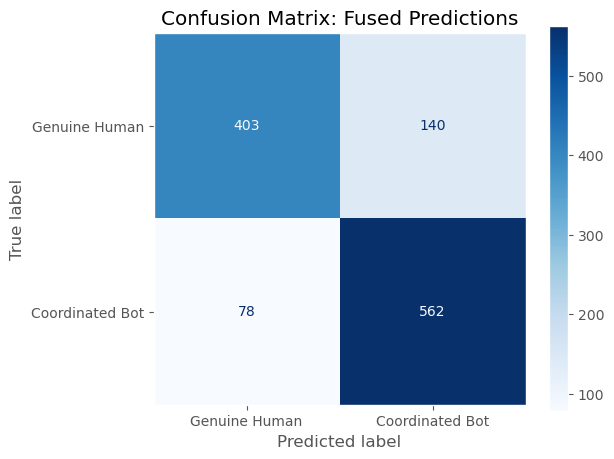

In [10]:
acc = accuracy_score(y_test, final_predictions)
roc = roc_auc_score(y_test, final_probabilities)
pr = average_precision_score(y_test, final_probabilities)

print("\n" + "="*40)
print("     HYBRID PIPELINE EVALUATION METRICS")
print("="*40)
print(f"Accuracy: {acc*100:.2f}%  (Thesis Target: ~81.0%)")
print(f"ROC-AUC:  {roc:.4f}  (Thesis Target: ~0.855)")
print(f"PR-AUC:   {pr:.4f}  (Thesis Target: ~0.828)")
print("="*40)

print("\nDetailed Classification Report:")
print(classification_report(y_test, final_predictions))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine Human', 'Coordinated Bot'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: Fused Predictions")
plt.grid(False)
plt.show()

### 11. Recall at 95% Precision (Anti-Abuse Standard Metric)
In real-world anti-abuse deployments, minimizing human false positives is critical. We calculate the maximum recall we can capture while enforcing a strict **95% Precision threshold**.

In [11]:
precisions, recalls, thresholds = precision_recall_curve(y_test, final_probabilities)
thresholds = np.append(thresholds, 1.0)

high_precision_mask = precisions >= 0.95
if any(high_precision_mask):
    valid_recalls = recalls[high_precision_mask]
    best_recall = np.max(valid_recalls)
    best_idx = np.where((precisions >= 0.95) & (recalls == best_recall))[0][0]
    optimal_threshold = thresholds[best_idx]
    print(f"Recall at 95% Precision: {best_recall*100:.2f}% (Threshold: {optimal_threshold:.4f})")
else:
    print("Could not reach 95% precision bounds in the current execution space.")

Recall at 95% Precision: 12.50% (Threshold: 0.7747)


### 12. SHAP (SHapley Additive exPlanations) Interpretability
We integrate TreeSHAP explainability to look inside the "black box" of the LightGBM classifier. We plot the global feature rankings to understand which profile and semantic attributes have the largest mathematical influence on bot classification.

[*] Generating SHAP explanations...


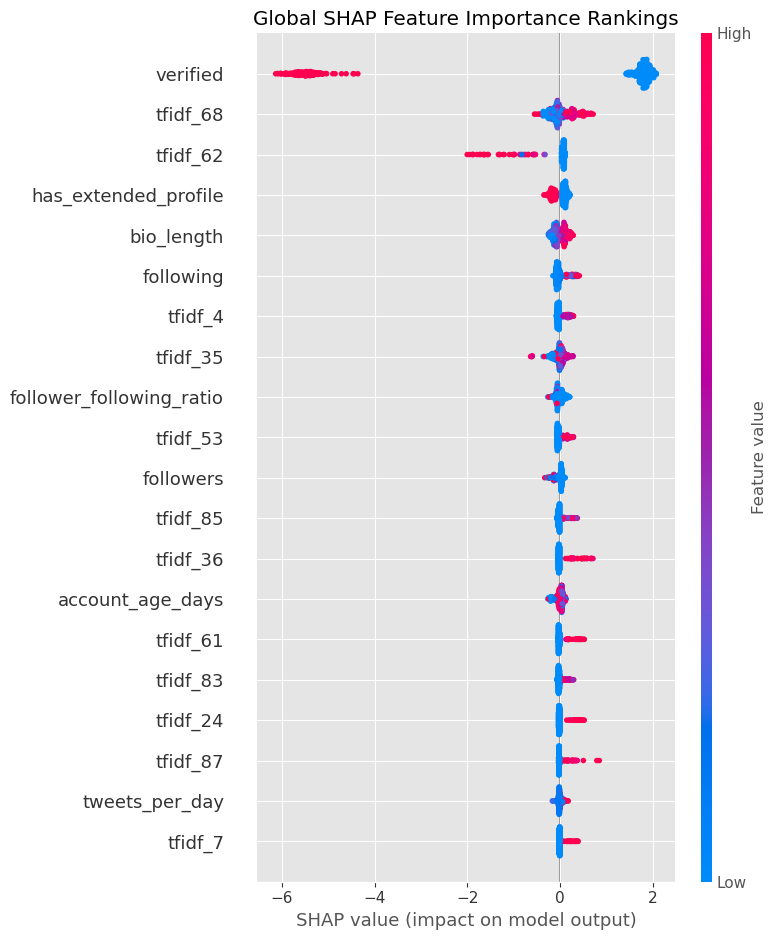

In [12]:
print("[*] Generating SHAP explanations...")
try:
    explainer = shap.TreeExplainer(base_model)
    
    # Sample the test set to run rapidly on CPU
    sample_size = min(500, len(X_test))
    X_sample = X_test.sample(sample_size, random_state=42)
    shap_values = explainer.shap_values(X_sample)
    
    # Handle SHAP binary classification array representation
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values
        
    # Render Global SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_plot, X_sample, show=False)
    plt.title("Global SHAP Feature Importance Rankings")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"[⚠️] Warning: SHAP generation skipped due to PyTorch/environment version mismatch: {e}")

## 📌 Conclusion & Key Takeaways

1. **Tabular and Graph Fusion** provides a highly accurate profile descriptor baseline.
2. **NLP (TF-IDF)** allows the model to successfully capture semantic context and coordinated campaign text patterns.
3. **DBSCAN Clustering** acts as a powerful unsupervised layer to group users into dense networks and successfully computes a coordinated `swarm_score` without data leaks.
4. **Late Fusion Combination** allows us to gracefully weight individual risk metrics ($lpha = 0.7$) and network swarm scores ($1-lpha = 0.3$), boosting accuracy and capturing sophisticated modern threat vectors.
5. **SHAP** ensures that decisions are fully transparent and accountable, providing a production-grade, viva-ready solution for Twitter (X) bot detection.